<a href="https://colab.research.google.com/github/SIMETHY/House-Price-Prediction/blob/main/House_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **House Price Prediction (Regression)**

# **Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.
Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

# **Objectives**

The objective of this task is to:
- Understand and explore the housing dataset.
- Perform data preprocessing including handling missing values, duplicates, and outliers.
- Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.
- Apply encoding, log transformation, and feature scaling where necessary.
- Train multiple regression algorithms to predict house prices.
- Evaluate and compare model performance using appropriate evaluation metrics.

# **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Data**

In [ ]:
df = pd.read_csv('house_price_regression_dataset.csv')
df

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


- Square_Footage – total area of the house in square feet
- Num_Bedrooms – number of bedrooms in the house
- Num_Bathrooms – number of bathrooms available
- Year_Built – year in which the house was constructed
- Lot_Size – size of the land area of the house
- Garage_Size – number of vehicles that can be parked in the garage
- Neighborhood_Quality – rating of the neighborhood (scale from 1 to 10)
- House_Price – price of the house

# **Understanding Variables**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [ ]:
#getting names of the columns
df.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

# **Basic checks**

In [ ]:
# number of rows and columns
df.shape

(1000, 8)

In [ ]:
# first 5 rows
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [ ]:
# Last rows
df.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [ ]:
# Summary of the dataset
df.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


# **Data Cleaning**

In [ ]:
# check for null values
df.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [ ]:
# check for duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


In [ ]:
df.value_counts()

,,,,,,,,count
Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price,
4999,5,1,1952,4.662712,2,5,1.060976e+06,1
503,5,2,2018,1.375014,0,9,2.060424e+05,1
504,3,1,1961,4.962978,0,10,1.497435e+05,1
505,5,3,1954,3.881538,0,3,1.591215e+05,1
509,2,1,2005,4.019228,0,3,1.793984e+05,1
...,...,...,...,...,...,...,...,...
594,2,2,2022,1.010484,1,9,1.588568e+05,1
577,5,3,1971,2.083123,1,10,1.855577e+05,1
566,1,3,2010,1.087256,0,1,1.584548e+05,1


# **Exploratory Data Analysis**

# **Univariate Analysis**

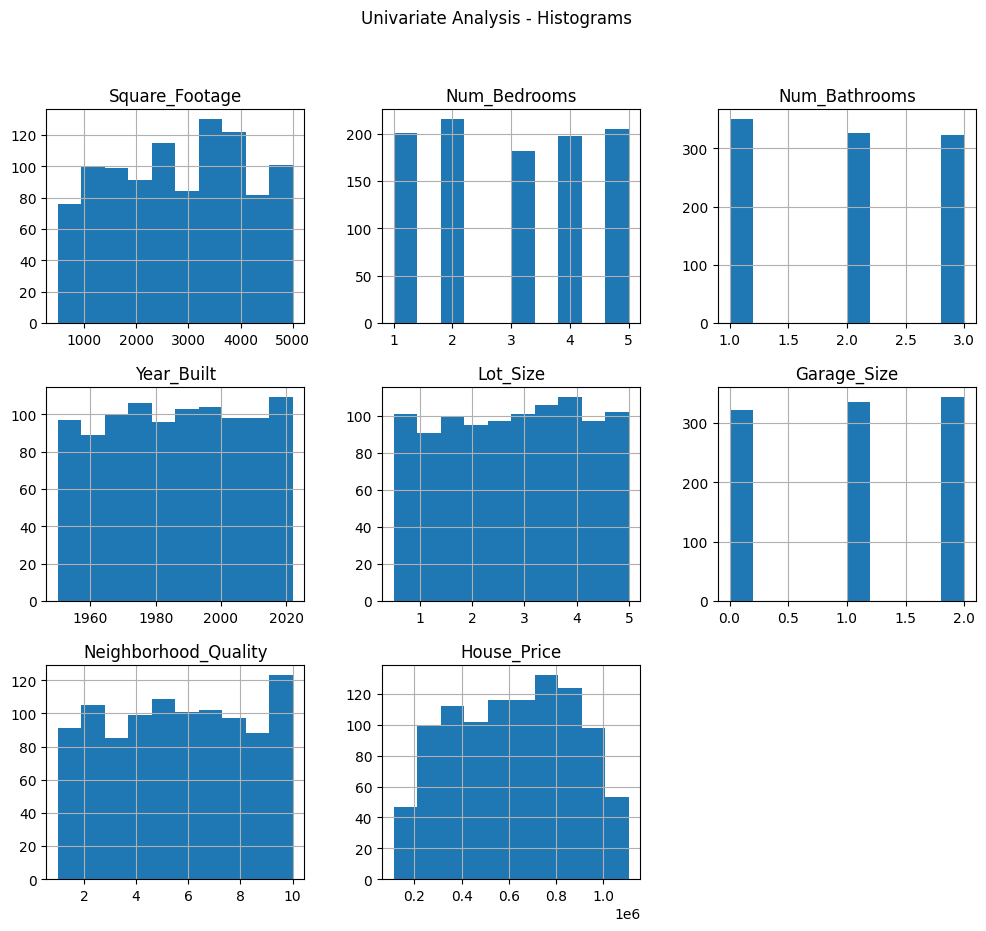

In [ ]:
df.hist(figsize=(12, 10))
plt.suptitle("Univariate Analysis - Histograms")
plt.show()

# **Bivariate Analysis**

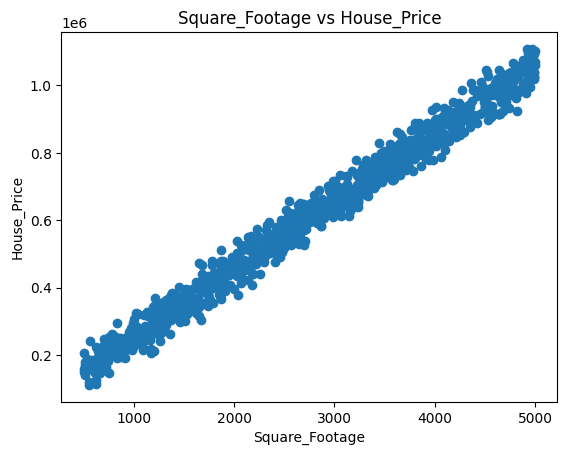

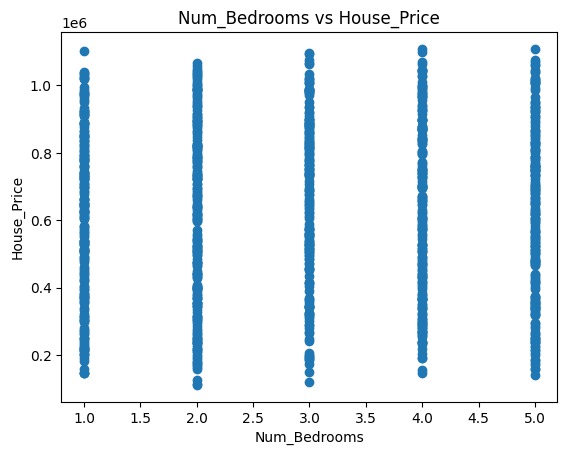

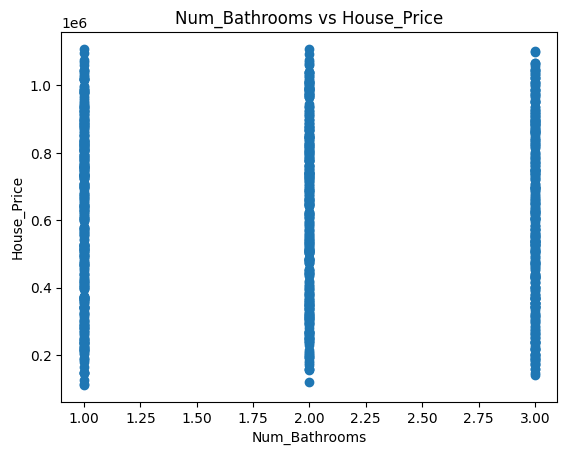

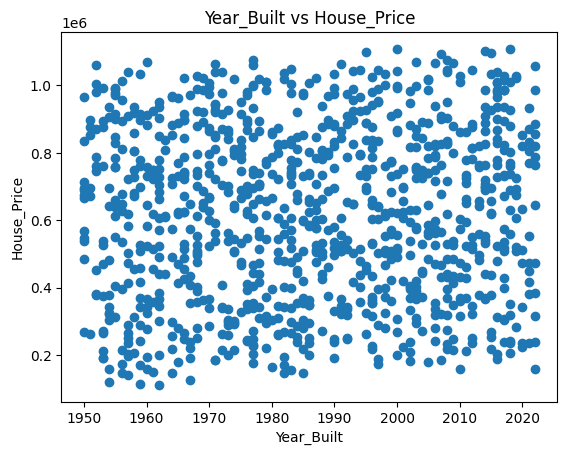

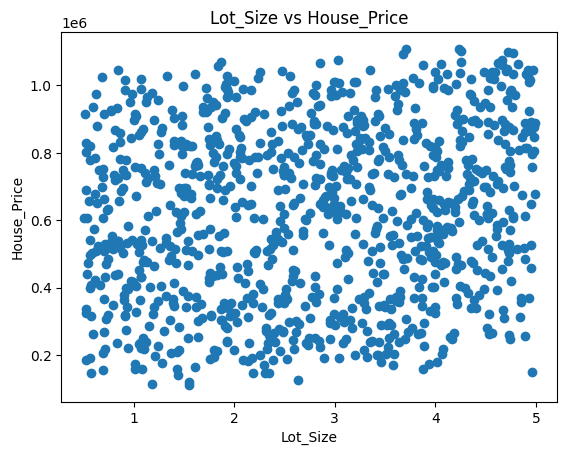

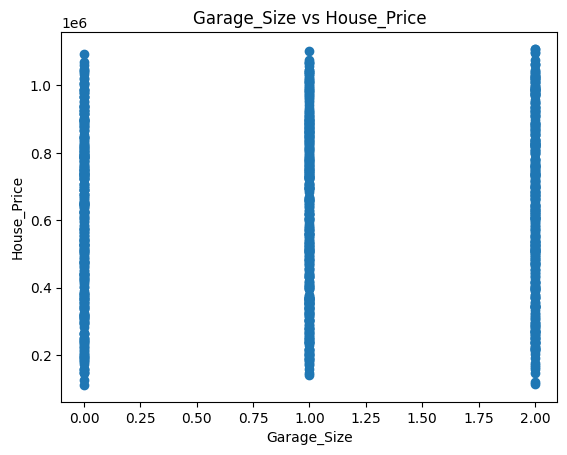

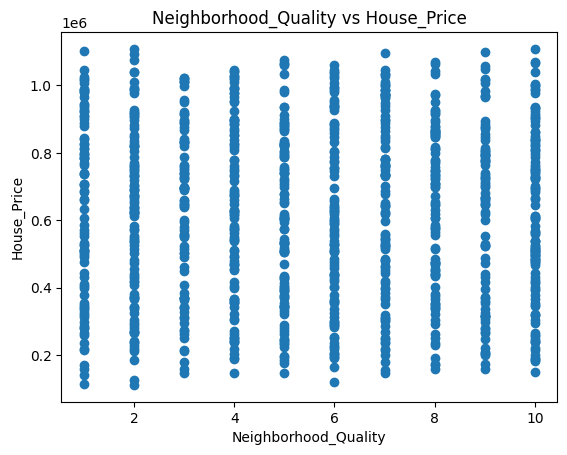

In [ ]:
target = "House_Price"

for column in df.columns:
    if column != target:
        plt.figure()
        plt.scatter(df[column], df[target])
        plt.xlabel(column)
        plt.ylabel(target)
        plt.title(f"{column} vs {target}")
        plt.show()

# **Multivariate Analysis**

# **CORRELATION HEATMAP**

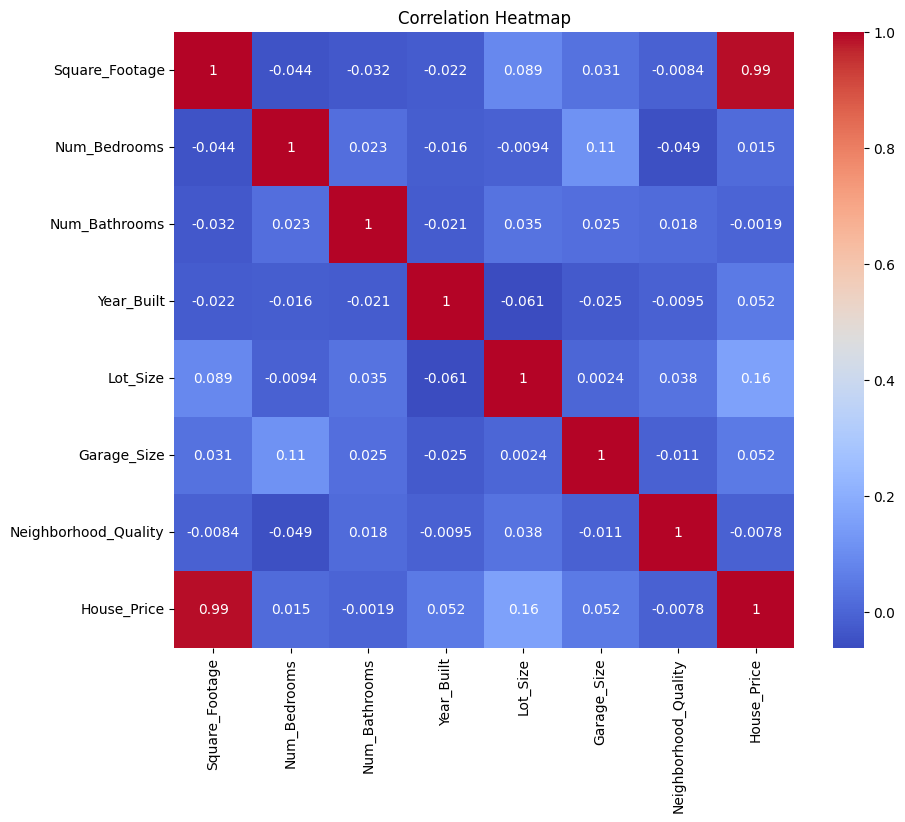

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# **Handling Outliers**

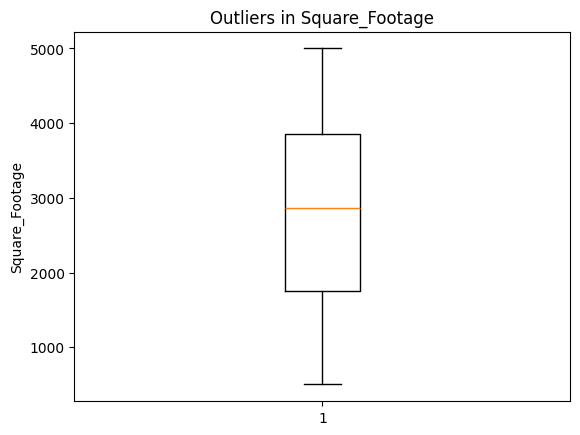

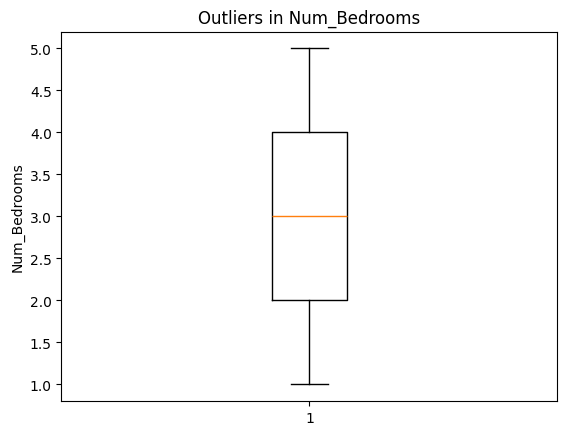

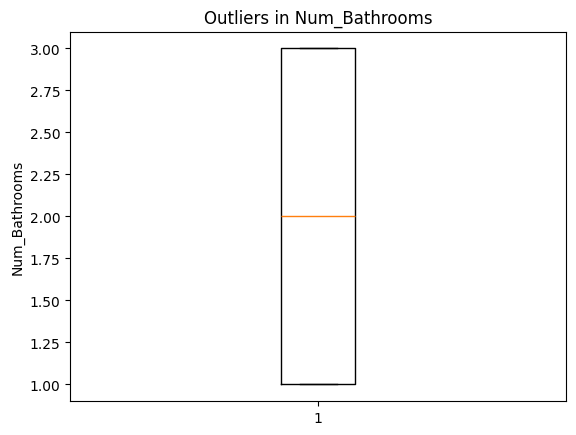

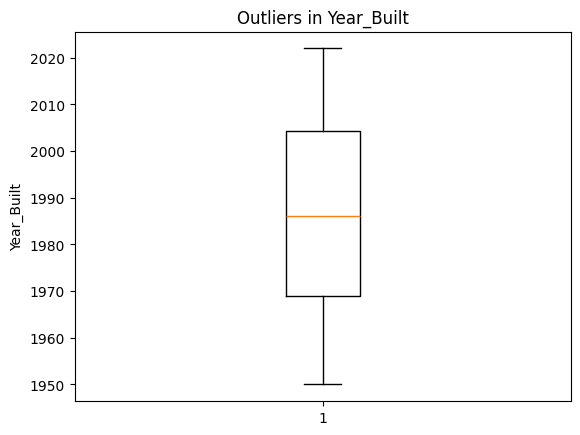

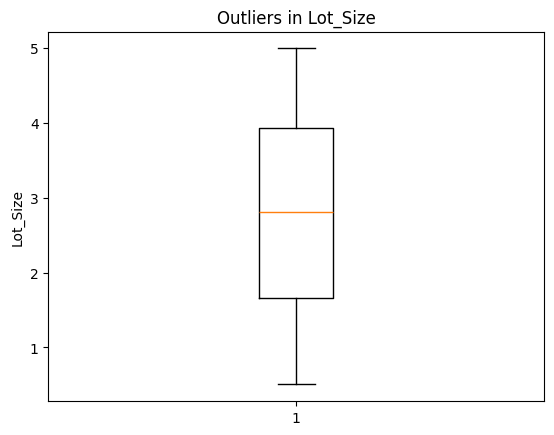

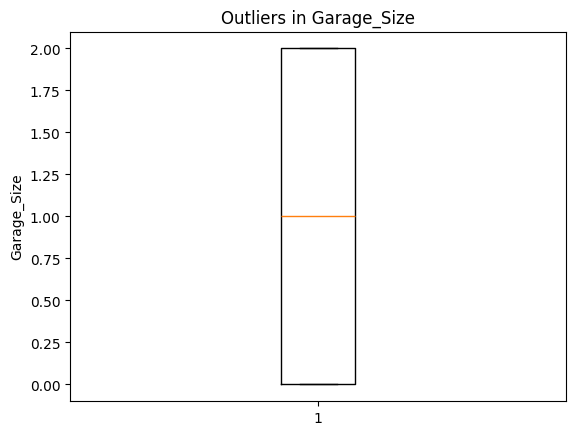

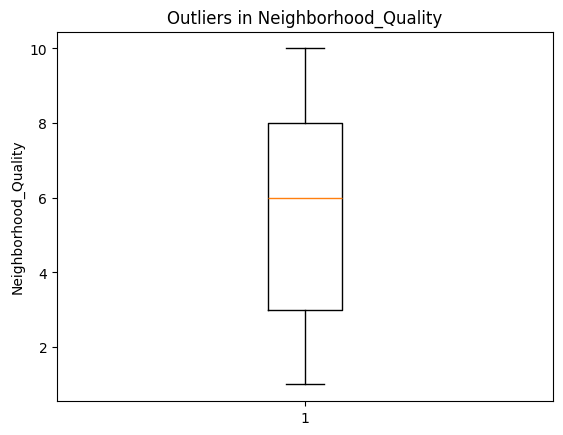

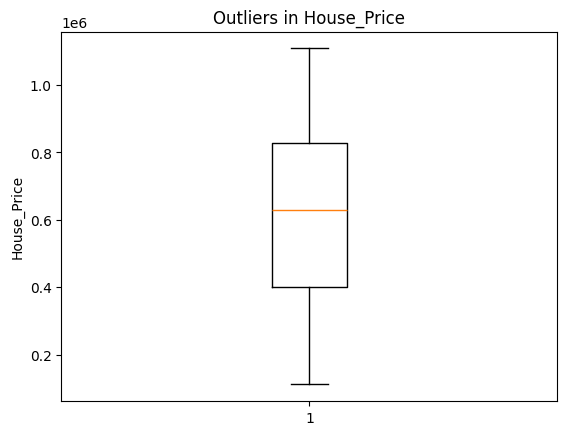

In [ ]:
for column in df.columns:
    plt.figure()
    plt.boxplot(df[column])
    plt.title(f"Outliers in {column}")
    plt.ylabel(column)
    plt.show()


# **Encoding**

Since there are no categorical columns so we don't need to perfrom the encoding

# **Features and Target Variables**

In [ ]:
X=df.drop(columns=['House_Price'])
y=df['House_Price']

In [ ]:
X.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality
0,1360,2,1,1981,0.599637,0,5
1,4272,3,3,2016,4.753014,1,6
2,3592,1,2,2016,3.634823,0,9
3,966,1,2,1977,2.730667,1,8
4,4926,2,1,1993,4.699073,0,8


In [ ]:
y.head()

,House_Price
0,2.623829e+05
1,9.852609e+05
2,7.779774e+05
3,2.296989e+05
4,1.041741e+06


# **Perfrom  Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Apply Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. STANDARDIZATION
scaler_standard = StandardScaler()
X_standard = scaler_standard.fit_transform(X)

# Convert back to DataFrame
X_standard_df = pd.DataFrame(X_standard, columns=X.columns)

print("Standardized Data:\n")
print(X_standard_df.head())

# 2. NORMALIZATION (Min-Max)

scaler_minmax = MinMaxScaler()
X_minmax = scaler_minmax.fit_transform(X)

# Convert back to DataFrame
X_minmax_df = pd.DataFrame(X_minmax, columns=X.columns)

print("\nMin-Max Scaled Data:\n")
print(X_minmax_df.head())


Standardized Data:

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0       -1.159803     -0.693836      -1.186699   -0.269122 -1.679278   
1        1.160724      0.007008       1.252559    1.428045  1.522390   
2        0.618843     -1.394681       0.032930    1.428045  0.660422   
3       -1.473776     -1.394681       0.032930   -0.463084 -0.036555   
4        1.681887     -0.693836      -1.186699    0.312764  1.480809   

   Garage_Size  Neighborhood_Quality  
0    -1.254658             -0.213126  
1    -0.027008              0.133420  
2    -1.254658              1.173060  
3    -0.027008              0.826514  
4    -1.254658              0.826514  

Min-Max Scaled Data:

   Square_Footage  Num_Bedrooms  Num_Bathrooms  Year_Built  Lot_Size  \
0        0.190614          0.25            0.0    0.430556  0.020873   
1        0.838301          0.50            1.0    0.916667  0.947295   
2        0.687055          0.00            0.5    0.916667  0.697880   
3 

This applies feature scaling using standardization and normalization to ensure all features are on the same scale, which helps improve model accuracy.

# **Train Regression Models**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [ ]:
# Knn Regression
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

# **Evaluation**

In [ ]:
def evaluate_model(y_test, y_pred, n_features):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Avoid division by zero in MAPE
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    r2 = r2_score(y_test, y_pred)

    # Adjusted R2
    n = len(y_test)
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)

    return mae, mse, rmse, mape, r2, adj_r2

In [ ]:
# Evaluating both models
n_features = X.shape[1]

lr_results = evaluate_model(y_test, y_pred_lr, n_features)
metrics = ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"]

print(" Linear Regression Results:")
for m, v in zip(metrics, lr_results):
    print(f"{m}: {v}")




 Linear Regression Results:
MAE: 8174.583600008702
MSE: 101434798.50566778
RMSE: 10071.484424138667
MAPE: 1.6639061459742324
R2: 0.9984263636823408
Adjusted R2: 0.9983689915249262


In [ ]:
n_features = X.shape[1]
knn_results = evaluate_model(y_test, y_pred_knn, n_features)
metrics = ["MAE", "MSE", "RMSE", "MAPE", "R2", "Adjusted R2"]

print("\n KNN Regression Results:")
for m, v in zip(metrics, knn_results):
    print(f"{m}: {v}")


 KNN Regression Results:
MAE: 26332.666984213156
MSE: 1047852097.5578195
RMSE: 32370.54367102628
MAPE: 5.480508096963195
R2: 0.9837438616673528
Adjusted R2: 0.9831511899573084
